In [31]:
import psycopg2 as db
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('../params.yaml', 'r') as file:
    connection_data = yaml.safe_load(file)['database']

db_connection = db.connect(
                dbname=connection_data['dbname'],
                user=connection_data['user'],
                password=connection_data['password'],
                host=connection_data['host'],
                port=connection_data['port']
            )
query = "SELECT t.* FROM public.temp_sensor t ORDER BY time_stamp DESC"
df = pd.read_sql_query(query, db_connection)

# Close the connection
db_connection.close()

C:\Users\denis\AppData\Local\Temp\ipykernel_1616\2078324356.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, db_connection)


In [32]:
df

,temp,humidity,time_stamp
0,24.7,48.0,2025-01-26 17:24:50.507731
1,24.7,48.0,2025-01-26 17:24:45.436154
2,24.7,48.0,2025-01-26 17:24:40.366129
3,24.7,48.0,2025-01-26 17:24:35.296237
4,24.7,48.0,2025-01-26 17:24:30.226132
...,...,...,...
194684,27.0,79.0,2024-05-15 23:26:12.129548
194685,27.0,80.0,2024-05-15 23:26:01.453409
194686,NaN,NaN,2024-05-15 23:25:50.787691
194687,55.0,79.0,2024-05-15 23:25:40.614282


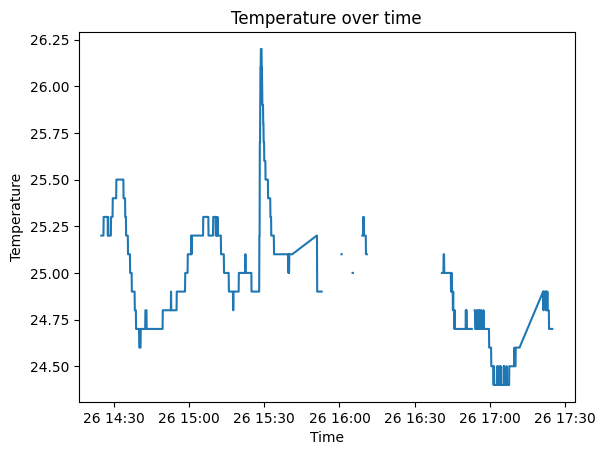

In [33]:
import datetime
timestamp_minus = datetime.datetime.now() - datetime.timedelta(hours=3)
df_filtered = df[df['time_stamp'] >= timestamp_minus]

plt.plot(df_filtered['time_stamp'], df_filtered['temp'])
plt.title('Temperature over time')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.show()

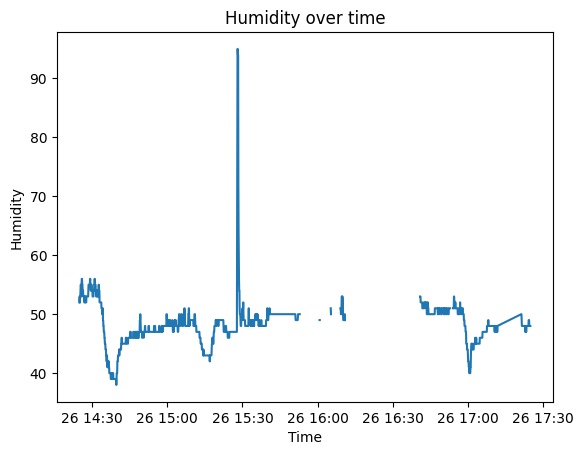

In [34]:
timestamp_minus = datetime.datetime.now() - datetime.timedelta(hours=3)
df_filtered = df[df['time_stamp'] >= timestamp_minus]

plt.plot(df_filtered['time_stamp'], df_filtered['humidity'])
plt.title('Humidity over time')
plt.xlabel('Time')
plt.ylabel('Humidity')
plt.show()